### Testing slow frequency sweeps
Sweeping in Python instead of Q1ASM which will be a slower sweep, and will require a new pulse for each frequency. The two QCM-RF outputs will go into frequency mixer, then the output of the mixer will be read using the QRM.

Author: Kyle MacRobbie

### Setup

In [1]:
# Imports
import json
import matplotlib.pyplot as plt
import pyvisa
import numpy as np
import scipy
from numpy import random
from __future__ import annotations
from typing import TYPE_CHECKING, Callable
from qcodes.instrument import find_or_create_instrument
from qblox_instruments import Cluster, ClusterType
if TYPE_CHECKING:
    from qblox_instruments.qcodes_drivers.module import Module

In [2]:
# Run to get cluster IP
!qblox-pnp list

Devices:
 - 192.168.137.2: cluster_mm 0.9.1 with name "cluster-mm" and serial number 00015_2251_003


In [3]:
# Connect to cluster
cluster_ip = "192.168.137.2"
cluster_name = "cluster0"
cluster = find_or_create_instrument(
    Cluster,
    recreate=True,
    name=cluster_name,
    identifier=cluster_ip,
    dummy_cfg=(
        {
            2: ClusterType.CLUSTER_QCM,
            4: ClusterType.CLUSTER_QRM,
            6: ClusterType.CLUSTER_QCM_RF,
        }
        if cluster_ip is None
        else None
    ),
)
cluster.led_brightness('medium') # Sets LED brightness on the modules. Options are 'low', 'medium' and 'high'

# Get modules, and connect to the QRM
def get_connected_modules(cluster: Cluster, filter_fn: Callable | None = None) -> dict[int, Module]:
    def checked_filter_fn(mod: ClusterType) -> bool:
        if filter_fn is not None:
            return filter_fn(mod)
        return True

    return {
        mod.slot_idx: mod for mod in cluster.modules if mod.present() and checked_filter_fn(mod)
    }
modules = get_connected_modules(cluster)
module = list(modules.values())[0]

cluster.led_brightness('medium')

# reset cluster and print cluster status
cluster.reset()
print(cluster.get_system_status())

Status: OKAY, Flags: NONE, Slot flags: NONE


In [4]:
modules
rf_module = modules[6]
qrm_module = modules[4]

In [5]:
print("\nQCM: {}\nQRM: {}\nRF: {}".format(rf_module.is_qcm_type, rf_module.is_qrm_type, rf_module.is_rf_type))


QCM: True
QRM: False
RF: True


In [6]:
print("\nQCM: {}\nQRM: {}\nRF: {}".format(qrm_module.is_qcm_type, qrm_module.is_qrm_type, qrm_module.is_rf_type))


QCM: False
QRM: True
RF: False


### Setting up some shortcuts to help make using the oscilloscope easier

In [7]:
rm = pyvisa.ResourceManager()
rm.list_resources()


('ASRL3::INSTR', 'GPIB0::8::INSTR')

In [8]:
scope = rm.open_resource('GPIB0::8::INSTR')
print(scope.query('*IDN?'))

*IDN LECROY,WP715ZI,LCRY0716N47852,8.5.0



### End of setup

---
---

### Making waveforms and defining our sweep parameters

In [47]:
# We will sweep one of the outputs of the QCM-RF
min_freq = 200e6 # Inlcusive
max_freq = 400e6 # Exclusive

# The other QCM-RF output will be stationary
stationary_freq = 100e6

n_steps = 4	# Number of steps
step_length = 10000	# length of each pulse
freq_spacing = ((max_freq - min_freq) / n_steps) # Size of frequency steps
print("Frequency spacing is: {:.4} Hz".format(freq_spacing))

# List of each step
freq_list = np.arange(min_freq, max_freq, freq_spacing)
print(freq_list)

Frequency spacing is: 5e+07 Hz
[2.0e+08 2.5e+08 3.0e+08 3.5e+08]


In [48]:
# Waveforms
waveform_length = step_length  # nanoseconds
waveforms = {
	"block": {
		"data": [1.0 for i in range(0, waveform_length)],
		"index": 0,
		}
}
acquisitions = {
    "acq": {"num_bins": 1, "index": 0},
}

### Making the sequences for our two outputs

In [ ]:
# Reset the phase of the NCO and begin the playing by setting the marker on for both outputs and markers
seq_out_0 = f"""
		reset_ph				# Reset the NCO phase to 0 degrees
		wait_sync	4			# Sync with the other sequencer
		set_mrk		{0b1111}	# Turn on all outputs and markers
		upd_param	4			# Update the marker values
"""

# Play the current frequency
seq_out_0 += f"""		
		play		0,0,{step_length} 	# Play the pulse
"""

# Set the markers to 0, disable the outputs, and stop the sequence
seq_out_0 += f"""
		set_mrk		{0b0000}	# Turn outputs and markers off
		upd_param	4			# Update the marker values
		stop					# Stop the sequence
	"""

In [50]:
# Reset the phase of the NCO and begin the playing by setting the marker on for both outputs and markers
seq_out_1 = f"""
		reset_ph				# Reset the NCO phase to 0 degrees
		wait_sync	4			# Sync with the other sequencer
"""

# Play the current frequency
seq_out_1 += f"""		
		play		0,0,{step_length} 	# Play the pulse
"""

# Set the markers to 0, disable the outputs, and stop the sequence
seq_out_1 += f"""
		stop					# Stop the sequence
	"""

In [51]:
# Sync with the other sequencers and wait 8 ns
seq_in = f"""
		wait_sync	4
"""

# Make an acquisition
seq_in += f"""
		acquire		0,0,{step_length}
"""

# Stop the sequencer
seq_in += f"""
		stop
"""

### Upload sequences

In [52]:
sequence_0 = {
	"waveforms": waveforms,
    "weights": {},
    "acquisitions": {},
    "program": seq_out_0,
}
sequence_1 = {
	"waveforms": waveforms,
    "weights": {},
    "acquisitions": {},
    "program": seq_out_1,
}
sequence_in = {
	"waveforms": {},
    "weights": {},
    "acquisitions": acquisitions,
    "program": seq_in,
}

# Upload sequences to their respective sequencers
rf_module.sequencer0.sequence(sequence_0)
rf_module.sequencer1.sequence(sequence_1)
qrm_module.sequencer0.sequence(sequence_in)

### Function that plays sequence

In [79]:
def play_sequence(nco_1, nco_2):
	rf_module.disconnect_outputs() 		    # Disconnect outputs
	qrm_module.disconnect_outputs()			# Disconnect outputs
	qrm_module.disconnect_inputs()			# Disconnect inputs
	rf_module.sequencer0.connect_out0(True) # Connect to the first output
	rf_module.sequencer1.connect_out1(True) # Connect to the second output
	qrm_module.sequencer0.connect_sequencer("in0")	# Connect the QRM input

	rf_module.sequencer0.mod_en_awg(True)   # Enable NCO modulation
	rf_module.out0_lo_en(True) 				# Enable LO modulation
	rf_module.sequencer0.nco_freq(nco_1) 	# Set NCO frequency
	rf_module.out0_lo_freq(3e9) 			# Set LO frequency

	rf_module.sequencer1.mod_en_awg(True)   # Enable NCO modulation
	rf_module.out1_lo_en(True) 				# Enable LO modulation
	rf_module.sequencer1.nco_freq(nco_2) 	# Set NCO frequency
	rf_module.out1_lo_freq(3e9) 			# Set LO frequency

	qrm_module.scope_acq_sequencer_select(0)	# Configure scope mode
	qrm_module.scope_acq_trigger_mode_path0("sequencer")
	qrm_module.scope_acq_trigger_mode_path1("sequencer")
	qrm_module.sequencer0.integration_length_acq(step_length)

	rf_module.sequencer0.sync_en(True)		# Enable sync
	rf_module.sequencer1.sync_en(True)		# Enable sync
	qrm_module.sequencer0.sync_en(True)		# Enable sync
	rf_module.arm_sequencer(0) 				# arm sequencer 0 rf
	rf_module.arm_sequencer(1) 				# arm sequencer 1 rf
	qrm_module.arm_sequencer(0)				# arm sequencer 0 qrm
	cluster.start_sequencer() 				# start sequencers
	
	# Move acquisition data from temporary memory to acquisition list.
	qrm_module.store_scope_acquisition(0, "acq")

	# Get acquisition list from instrument.
	non_weighed_acq = qrm_module.get_acquisitions(0)["acq"]

	return non_weighed_acq

### Oscilloscope shortcuts to set the scales, turn to single acquisition

In [55]:
scope.write(f'TIME_DIV {1e-6} S') # Setting time scale
scope.write(f'C3:VOLT_DIV {0.5} V')   # Setting voltage scale on channel 3
scope.write(f'TRIG_DELAY -2e-8')		# Setting the time offset
scope.write(f'TRIG_MODE SINGLE')	# Turn to single acquisition mode

18

### Play the sequence

In [80]:
acqs = []
for freq in freq_list:
	acqs.append(play_sequence(stationary_freq, freq))

print(rf_module.get_sequencer_status(0))

Status: OKAY, State: STOPPED, Info Flags: NONE, Warning Flags: NONE, Error Flags: NONE, Log: []


### Plotting

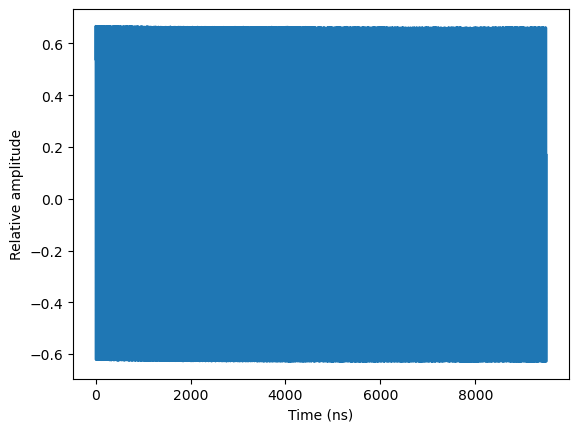

In [81]:
fig, ax = plt.subplots(1, 1)
ax.plot(acqs[0]["acquisition"]["scope"]["path0"]["data"][500:10000])
ax.set_xlabel("Time (ns)")
ax.set_ylabel("Relative amplitude")
plt.show()

### Generating and plotting a periodogram

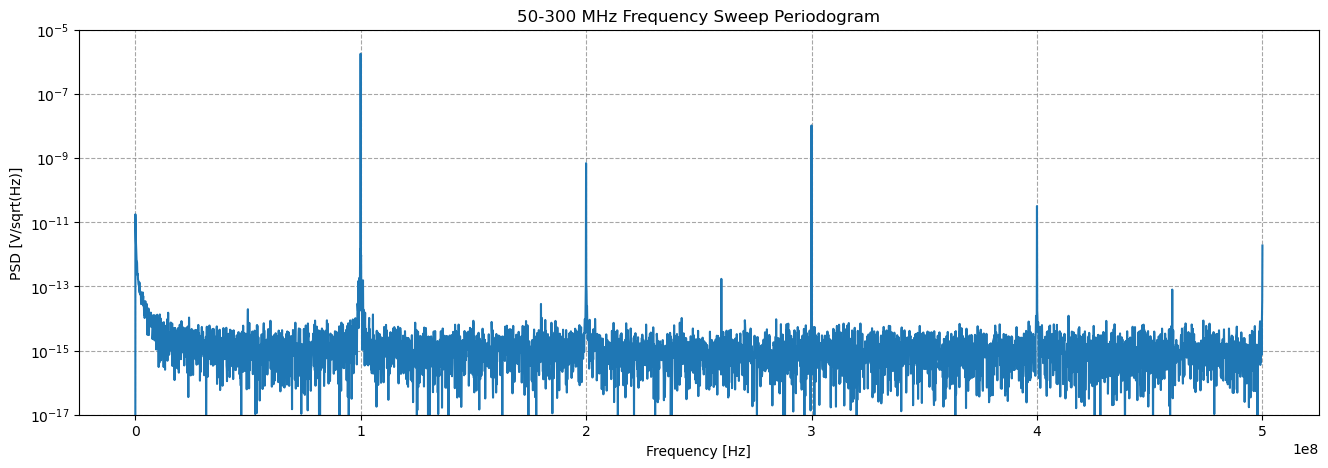

In [84]:
# Generating periodogram data
freqs, psd = scipy.signal.periodogram(acqs[0]["acquisition"]["scope"]["path0"]["data"][500:10000], 1e9)

# Create plot
fig, ax = plt.subplots(1, 1, figsize=(16,5))

# Set titles
ax.set_title("50-300 MHz Frequency Sweep Periodogram")
ax.set_ylabel("PSD [V/sqrt(Hz)]")
ax.set_xlabel("Frequency [Hz]")

ax.set_yscale("log") # Set y scale to log
ax.grid(color = "grey", linestyle = "--", alpha = 0.7) # Add a grid
ax.set_ylim([1e-17, 1e-5]) # Set bounds for the y axis
ax.plot(freqs, psd)
plt.show()

### Stopping

In [85]:
rf_module.stop_sequencer(0)

# Print status of sequencer.
print(rf_module.get_sequencer_status(0))

# Reset the cluster
cluster.reset()
print(cluster.get_system_status())

Status: OKAY, State: STOPPED, Info Flags: FORCED_STOP, Warning Flags: NONE, Error Flags: NONE, Log: []
Status: OKAY, Flags: NONE, Slot flags: NONE
